In [17]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm

In [31]:
#function
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

#current1
def Gr_DD_MS(H_q1,H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q1.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i < N//2:
            H_qi = H_q1
        else:
            H_qi = H_q2

        # 左端点
        if i == 0:
            A_DD[i][i] = EI_gai - H_qi - Sigma_L

        # 右端点
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_qi - Sigma_R

        # 中间
        else:
            A_DD[i][i] = EI_gai - H_qi

        # hopping
        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD_wn = np.block(A_DD)
    G_DD_wn = np.linalg.inv(A_DD_wn)
    return G_DD_wn , A_DD_wn , Sigma_R , Sigma_L 

def J_wn(G_DD_wn, T_12, q):
    d = T_12.shape[0]

    G_q_q1 = G_DD_wn[q*d:(q+1)*d, (q+1)*d:(q+2)*d]
    G_q1_q = G_DD_wn[(q+1)*d:(q+2)*d, q*d:(q+1)*d]

    Jmat = T_12.conj().T @ G_q_q1 - G_q1_q @ T_12
    d_e = d //2
    return np.trace(Jmat[:d_e, :d_e])*(-1j)*KBT
    #return np.trace(Jmat)*(-1j)*KBT

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_matsubara_sum(shumu,H_q1,H_q2, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        G_DD_wn, _, _, _ = Gr_DD_MS(
            H_q1, H_q2, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, wn
        )

        J_sum += np.real(J_wn(G_DD_wn, T_12, q))
    return (J_sum)



In [1]:
#右边
t_R=25
mu_R=0

Vz=2
varphi_s = np.pi*0  #z_x平面

delta=1
chaodaojiao=0

alpha_R=2
a=1

#左边
t_L=30
mu_L=0


#中间 前10与后10
t_c=15


V_f=0     #前10
varphi_f = np.pi*0


T_Tc=0.01
Delta = delta * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
dianshubei=1#8
KBT=2 * delta * T_Tc / 3.5
shumu=int(np.floor(50*delta/(2*np.pi*KBT)))*dianshubei


N=20
q=2

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(t,u,m_zx,Bjiao, weizhi,weizhi_zhongjian_qianyuhou):
    if weizhi==1:
        Delta_X= np.zeros((2,2))
        HX_block=-(u-2*t)*s0 + m_zx*np.cos(Bjiao)*sz+ m_zx*np.sin(Bjiao)*sx
    if weizhi==2:
        if weizhi_zhongjian_qianyuhou==1:
            Delta_X= np.zeros((2,2))
            HX_block=-(u-2*t)*s0 + m_zx*np.cos(Bjiao)*sz+ m_zx*np.sin(Bjiao)*sx
        if weizhi_zhongjian_qianyuhou==2:
            Delta_X= np.zeros((2,2))
            HX_block=-(u-2*t)*s0
    elif weizhi==3:
        Delta_X= Delta * np.exp(1j*chaodaojiao) * 1j * sy
        HX_block=-(u-2*t)*s0 + m_zx*np.cos(Bjiao)*sz+ m_zx*np.sin(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(t,alpha_R):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*alpha_R*sy/(2*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(t_L,mu_L,   0,0,   1,3)
H_L_right_to_left_hop=H_hop(t_L,0)

#中间矩阵信息
H_center_to_L=H_hop(t_L,0)

H_center_qian =H_onsite(t_L,mu_L,   V_f,varphi_f,   2,1)
H_center_hou  =H_onsite(t_L,mu_L,      0,0,         2,2)
H_center_right_to_left_hop=H_hop(t_L,0)

H_R_to_center=H_hop(t_c,0)

#右边矩阵信息
H_R_onsite=H_onsite(t_R,mu_R, Vz,varphi_s,   3,3)
H_R_right_to_left_hop=H_hop(t_R, alpha_R)

#输入矩阵
H_q1=H_center_qian
H_q2=H_center_hou
T_12= H_center_right_to_left_hop.conj().T

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center

#shumu*2*np.pi*KBT/Delta

NameError: name 'np' is not defined

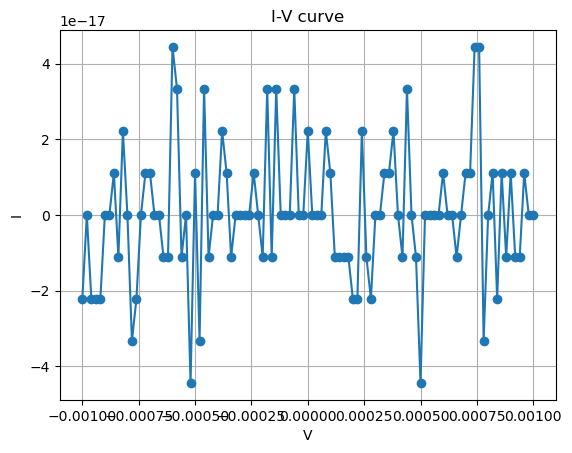

In [29]:
def current_vs_V(V):

    muL = mu_L + V/2
    muR = mu_R - V/2

    H_l = H_onsite(t_L, muL, 0, 0, 1, 3)
    H_q1=H_onsite(t_L,muL,   V_f,varphi_f,   2,1)
    H_q2=H_onsite(t_L,muL,      0,0,         2,2)
    H_r = H_onsite(t_R, muR, Vz, varphi_s, 3, 3)

    J = J_matsubara_sum(
        shumu,
        H_q1, H_q2,
        H_l, H_r,
        T_12, T_LD, T_l, T_RD, T_r,
        N, q
    )

    return J
V_list = np.linspace(-0.001, 0.001, 101)
I_list = []

for V in V_list:
    I = current_vs_V(V)
    I_list.append(I)
import matplotlib.pyplot as plt

plt.plot(V_list, I_list, 'o-')
plt.xlabel("V")
plt.ylabel("I")
plt.title("I-V curve")
plt.grid()
plt.show()